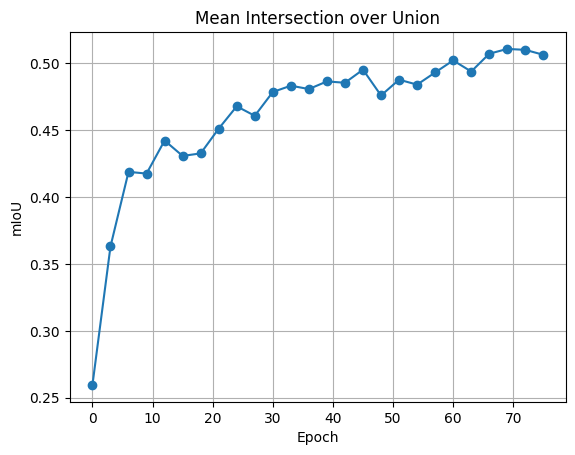

In [1]:
import re
import matplotlib.pyplot as plt

log_file = r"D:\inProgress\DeepLearning\Project\PIDNet\output_small\ade20k\pidnet_small_ade20k_trainval\pidnet_small_ade20k_trainval_2026-03-23-09-47_train.log"

epochs = []
miou_list = []

with open(log_file, "r", encoding="utf-8") as f:
    for line in f:
        if "MeanIU:" in line:
            miou = float(re.search(r"MeanIU:\s+([0-9.]+)", line).group(1))
            
            epoch = len(epochs)
            epochs.append(epoch)
            miou_list.append(miou)

# ===== LỌC THEO VALIDATION (mỗi 3 epoch) =====
filtered_epochs = []
filtered_miou = []

for i, (e, m) in enumerate(zip(epochs, miou_list)):
    if i % 3 == 0:
        filtered_epochs.append(e)
        filtered_miou.append(m)

# ===== VẼ =====
plt.figure()
plt.plot(filtered_epochs, filtered_miou, marker='o')

plt.xlabel("Epoch")
plt.ylabel("mIoU")
plt.title("Mean Intersection over Union")
plt.grid()

plt.savefig("miou_plot_clean.png")
plt.show()

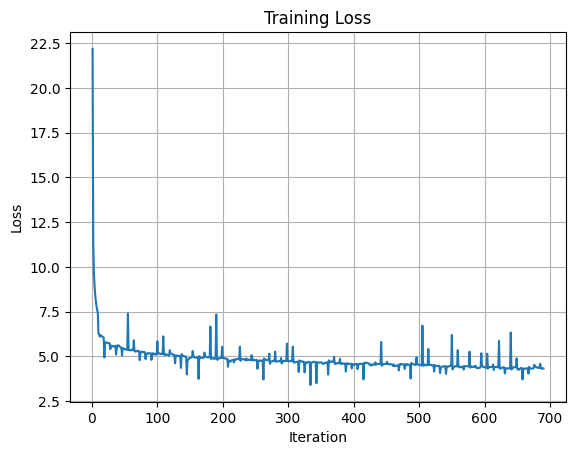

In [3]:
import re
import matplotlib.pyplot as plt

log_file = r"D:\inProgress\DeepLearning\Project\PIDNet\output_small\ade20k\pidnet_small_ade20k_trainval\pidnet_small_ade20k_trainval_2026-03-23-09-47_train.log"

iters = []
losses = []

with open(log_file, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if "Loss:" in line and "Epoch" in line:
            match = re.search(r"Loss:\s+([0-9.]+)", line)
            if match:
                losses.append(float(match.group(1)))
                iters.append(len(losses))

plt.figure()
plt.plot(iters, losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid()

plt.savefig("loss_plot.png")
plt.show()